In [32]:
import sys
import os

# Détection automatique de la racine du projet
# On remonte d'un niveau depuis le dossier 'notebooks'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Ajout au path pour pouvoir faire "from src..."
if project_root not in sys.path:
    sys.path.append(project_root)

# Définition des chemins absolus
DATA_RAW = os.path.join(project_root, "data", "raw")
DATA_PROCESSED = os.path.join(project_root, "data", "processed")
GEO_PATH = os.path.join(project_root, "geo")

print(f"Système configuré. Racine : {project_root}")


Système configuré. Racine : c:\Users\valen\OneDrive\Documents\GitHub\Projet-de-Statapp---WFP-


In [33]:
import sys
import os
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from xgboost import XGBRegressor

# --- 1. CONFIGURATION SYSTEME ---
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Chemins
DATA_PROCESSED = os.path.join(project_root, "data", "processed")
filepath = os.path.join(DATA_PROCESSED, "NIGERIA_WFP_ENGINEERED.csv")

# Chargement du DataFrame 
df = pd.read_csv(filepath)
print(f"Système configuré. Racine : {project_root}")

Système configuré. Racine : c:\Users\valen\OneDrive\Documents\GitHub\Projet-de-Statapp---WFP-


In [34]:
# 1. Identification de toutes les colonnes contenant "Proxy" (indépendamment de la casse)
cols_proxy = [c for c in df.columns if 'proxy' in c.lower()]
print(f"Colonnes à supprimer : {cols_proxy}")

# 2. Création du DataFrame final "propre"
df_final = df.drop(columns=cols_proxy)

# 3. Vérification des colonnes restantes
print(f"\nNombre de colonnes après nettoyage : {len(df_final.columns)}")

Colonnes à supprimer : ['flooded_area_proxy', 'population_exposed_proxy', 'WSI_Proxy', 'WSI_Proxy_Lag_1', 'WSI_Proxy_Lag_2', 'WSI_Proxy_Lag_3', 'WSI_Proxy_Lag_4', 'WSI_Proxy_Lag_5', 'WSI_Proxy_Lag_6']

Nombre de colonnes après nettoyage : 71


# Régressions

### LHZ

In [35]:
# --- 2. RÉGRESSION LHZ (STRUCTURELLE) ---
df_reg = df.copy()
df_reg = df_reg.dropna(subset=["dominant_livelihood_zone", "inadequate"])

model_lhz = smf.ols("inadequate ~ C(dominant_livelihood_zone)", data=df_reg).fit()

print("\n=== ANOVA RESULTS (RAW LEVELS) ===")
# typ=2 est standard pour les modèles non équilibrés
anova_table = sm.stats.anova_lm(model_lhz, typ=2)
print(anova_table)

print("\n=== COEFFICIENTS LHZ ===")
print(model_lhz.summary())



=== ANOVA RESULTS (RAW LEVELS) ===
                                sum_sq     df          F        PR(>F)
C(dominant_livelihood_zone)  13.639993   15.0  38.556857  2.840455e-86
Residual                     21.131449  896.0        NaN           NaN

=== COEFFICIENTS LHZ ===
                            OLS Regression Results                            
Dep. Variable:             inadequate   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     38.56
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.84e-86
Time:                        10:30:15   Log-Likelihood:                 422.71
No. Observations:                 912   AIC:                            -813.4
Df Residuals:                     896   BIC:                            -736.4
Df Model:                          15                                         
Covariance Typ

### Geographical Structure Analysis (LHZ)

The ANOVA analysis demonstrates a massive effect of the livelihood zone on food security ($F = 38.56, p < 0.001$). 

**Key Findings:**
* **The North-South Divide:** The model reveals a stark contrast in Nigeria. While the Northern savanna and Sahelian zones (such as Kano, Katsina, and Sokoto) gravitate around **60% food insecurity**, the forest and cocoa-producing zones of the South-West drop to near-zero levels in comparison.
* **The Role of Diversification:** Zones with the most significant negative coefficients (notably `Lagos Peri-urban` and `South-east oil palm`) are those that do not rely solely on rain-fed cereals. This confirms that the economic and agricultural structure of a zone serves as the primary bulwark against hunger.
* **Predictive Power:** With an Adjusted $R^2$ of **38.2%**, the geographical zone is a more determining factor for food insecurity than isolated climate anomalies. This suggests that vulnerability is structurally "anchored" in specific regions regardless of temporary shocks.

In [36]:
# --- 3. RÉGRESSION AVEC INTERACTIONS (MÉCANISMES) ---
# Nettoyage des variables climatiques
climate_vars = ['WSI_Lag_3', 'Tair_f_tavg', 'ndvi_anomaly']
df_margin = df.dropna(subset=['inadequate', 'geopolitical_region'] + climate_vars).copy()

# Modèle avec interaction (*) pour tester si l'effet du climat dépend de la région
formula = "inadequate ~ geopolitical_region * (WSI_Lag_3 + Tair_f_tavg + ndvi_anomaly)"
model_inter = smf.ols(formula, data=df_margin).fit()

print("\n=== INTERACTION MODEL SUMMARY ===")
print(model_inter.summary())


=== INTERACTION MODEL SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:             inadequate   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     56.98
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           7.07e-67
Time:                        10:30:15   Log-Likelihood:                 333.23
No. Observations:                 855   AIC:                            -650.5
Df Residuals:                     847   BIC:                            -612.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

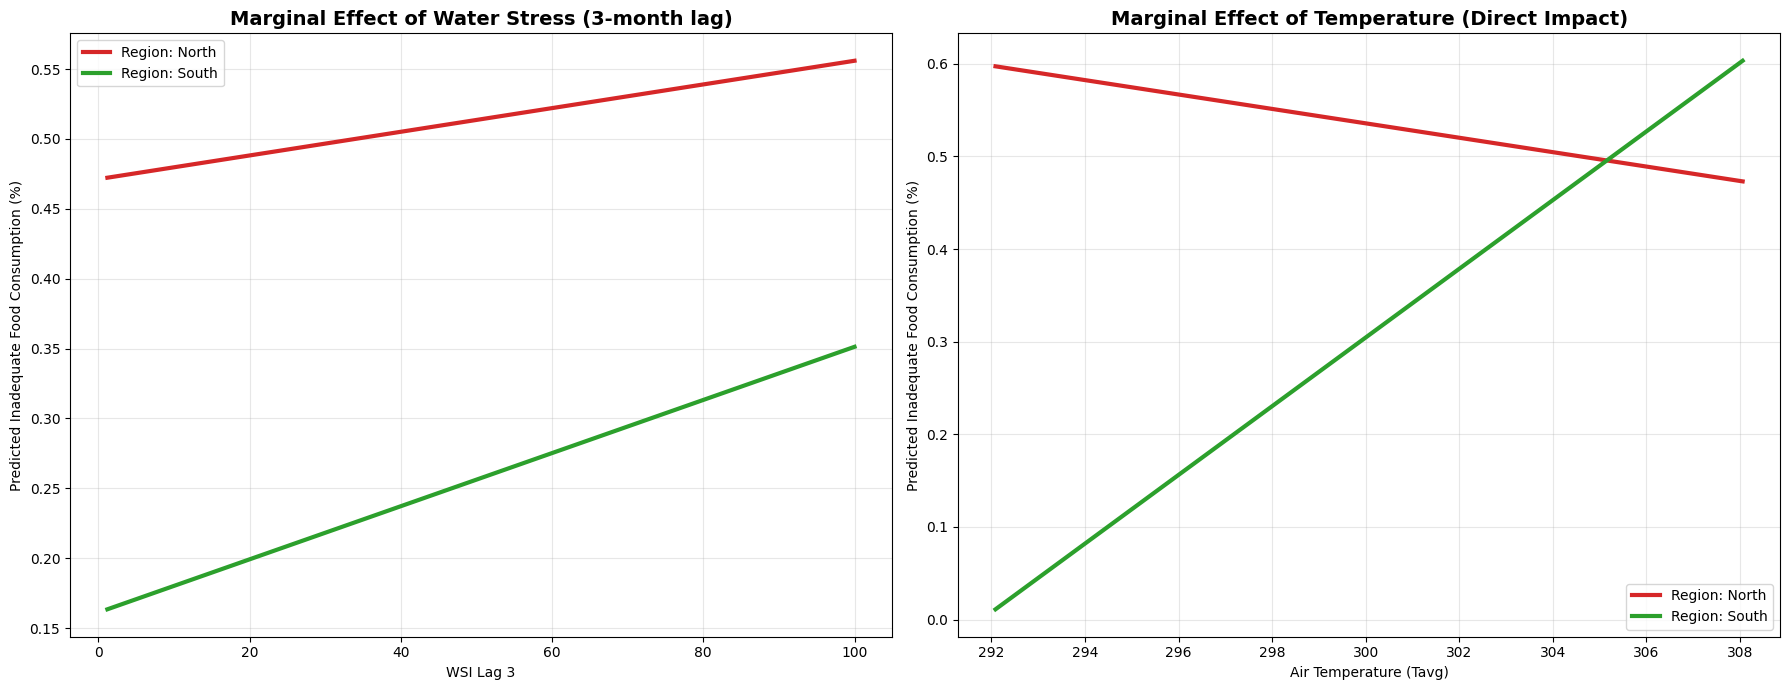

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Préparation des plages de données
# On crée un vecteur allant du min au max pour chaque variable
wsi_range = np.linspace(df_margin['WSI_Lag_3'].min(), df_margin['WSI_Lag_3'].max(), 100)
temp_range = np.linspace(df_margin['Tair_f_tavg'].min(), df_margin['Tair_f_tavg'].max(), 100)

# 2. Création de la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- GRAPHIQUE A : EFFET DU WSI_LAG_3 ---
for region, color in zip(['North', 'South'], ['#d62728', '#2ca02c']):
    # On crée un DataFrame de test où seule la variable d'intérêt change
    test_df = pd.DataFrame({
        'WSI_Lag_3': wsi_range,
        'geopolitical_region': region,
        'Tair_f_tavg': df_margin['Tair_f_tavg'].mean(),
        'ndvi_anomaly': df_margin['ndvi_anomaly'].mean()
    })
    preds = model_inter.predict(test_df)
    ax1.plot(wsi_range, preds, color=color, linewidth=3, label=f'Region: {region}')

ax1.set_title("Marginal Effect of Water Stress (3-month lag)", fontsize=14, fontweight='bold')
ax1.set_xlabel("WSI Lag 3")
ax1.set_ylabel("Predicted Inadequate Food Consumption (%)")
ax1.legend()
ax1.grid(alpha=0.3)

# --- GRAPHIQUE B : EFFET DE LA TEMPÉRATURE ---
for region, color in zip(['North', 'South'], ['#d62728', '#2ca02c']):
    test_df = pd.DataFrame({
        'Tair_f_tavg': temp_range,
        'geopolitical_region': region,
        'WSI_Lag_3': df_margin['WSI_Lag_3'].mean(),
        'ndvi_anomaly': df_margin['ndvi_anomaly'].mean()
    })
    preds = model_inter.predict(test_df)
    ax2.plot(temp_range, preds, color=color, linewidth=3, label=f'Region: {region}')

ax2.set_title("Marginal Effect of Temperature (Direct Impact)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Air Temperature (Tavg)")
ax2.set_ylabel("Predicted Inadequate Food Consumption (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Interaction Mechanisms

The interaction model ($R^2 = 0.32$) provides a  view of how climate shocks translate into hunger differently across Nigeria.

**Key Findings:**
* **Thermal Sensitivity in the South:** The most striking result is the interaction between the South and temperature ($coef = 0.0448, p < 0.001$). While heat has a negligible direct effect in the North, it significantly deteriorates food security in the South. This validates our hypothesis regarding the vulnerability of Southern food systems (root crops spoilage and storage constraints) to immediate thermal shocks.
* **Universal Water Stress:** The impact of `WSI_Lag_3` is positive and significant across all regions, confirming that rainfall deficits 3 months prior are a nationwide driver of food insecurity, regardless of the local agricultural system.
* **Geopolitical Resilience:** The large negative coefficient for the `South` intercept (-13.76) demonstrates a massive structural advantage, likely due to higher economic diversification and market integration, which acts as a buffer that the North lacks.

**Methodological Conclusion:**
The high condition number confirms significant multicollinearity between environmental variables. While the OLS identifies these critical "channels" of impact, non-linear ensemble models (Machine Learning) will be required in the next phase to maximize predictive accuracy.

# Cross-Validation

## Lasso

In [47]:

# Préparation pour Lasso (Toutes variables numériques)
exclude_cols = ['inadequate', 'NAME_1', 'time', 'bnds', 'year', 'month']
all_features = df_final.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in all_features if c not in exclude_cols]

df_full = df_final.dropna(subset=['inadequate']).copy()
X_full = pd.get_dummies(df_full[all_features + ['geopolitical_region']], drop_first=True)
y_full = df_full['inadequate']

# Nettoyage strict des NaNs pour Scikit-Learn
X_full = X_full.dropna(axis=1, how='all')
final_idx = X_full.dropna().index
X_final = X_full.loc[final_idx]
y_final = y_full.loc[final_idx]

# Split chronologique pour éviter le data leakage
# On trie par temps avant le split
X_final = X_final.sort_index() # Assure-toi que l'index suit le temps ou trie par df_full['time']
tscv = TimeSeriesSplit(n_splits=5)

In [48]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# 1. Préparation du pool de variables
# On exclut les colonnes non-prédictives
exclude = ['inadequate', 'NAME_1', 'time', 'bnds', 'year', 'month', 'Region', 'dominant_livelihood_zone']
all_numeric_features = df_final.select_dtypes(include=[np.number]).columns.tolist()
features_to_test = [c for c in all_numeric_features if c not in exclude]

# Ajout de la région en dummy (variable catégorielle clé)
X_selection = pd.get_dummies(df[features_to_test + ['geopolitical_region']], drop_first=True)
y_selection = df['inadequate']

# 2. Nettoyage strict pour Scikit-Learn (Lasso déteste les NaNs)
# On aligne X et y sur les lignes qui n'ont aucun NaN
data_for_lasso = pd.concat([X_selection, y_selection], axis=1).dropna()
X_final = data_for_lasso.drop(columns=['inadequate'])
y_final = data_for_lasso['inadequate']

# 3. Standardisation (L'étape ENSAE : le Lasso pénalise la taille des coefs, 
# donc toutes les variables doivent être sur la même échelle)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# 4. Fit LassoCV (Recherche l'alpha optimal par validation croisée)
lasso = LassoCV(cv=5, max_iter=10000, random_state=42).fit(X_scaled, y_final)

# 5. Extraction des survivantes
lasso_coefs = pd.Series(lasso.coef_, index=X_final.columns)
selected_features = lasso_coefs[lasso_coefs != 0].sort_values(ascending=False)

print(f"Lasso a réduit le dataset de {X_final.shape} à {len(selected_features)} variables.")
print("\nTop 10 des variables les plus influentes (positives) :")
print(selected_features.head(10))

Lasso a réduit le dataset de (698, 63) à 42 variables.

Top 10 des variables les plus influentes (positives) :
Qair_f_tavg           0.102695
WSI_Lag_2             0.044317
Wind_f_tavg           0.032223
soil_anomaly          0.029452
interact_ndvi_lean    0.026318
WSI_Lag_5             0.026302
FPAR_Lag_6            0.024531
WSI_Lag_3             0.024318
FPAR_Zscore           0.019830
Y                     0.019541
dtype: float64


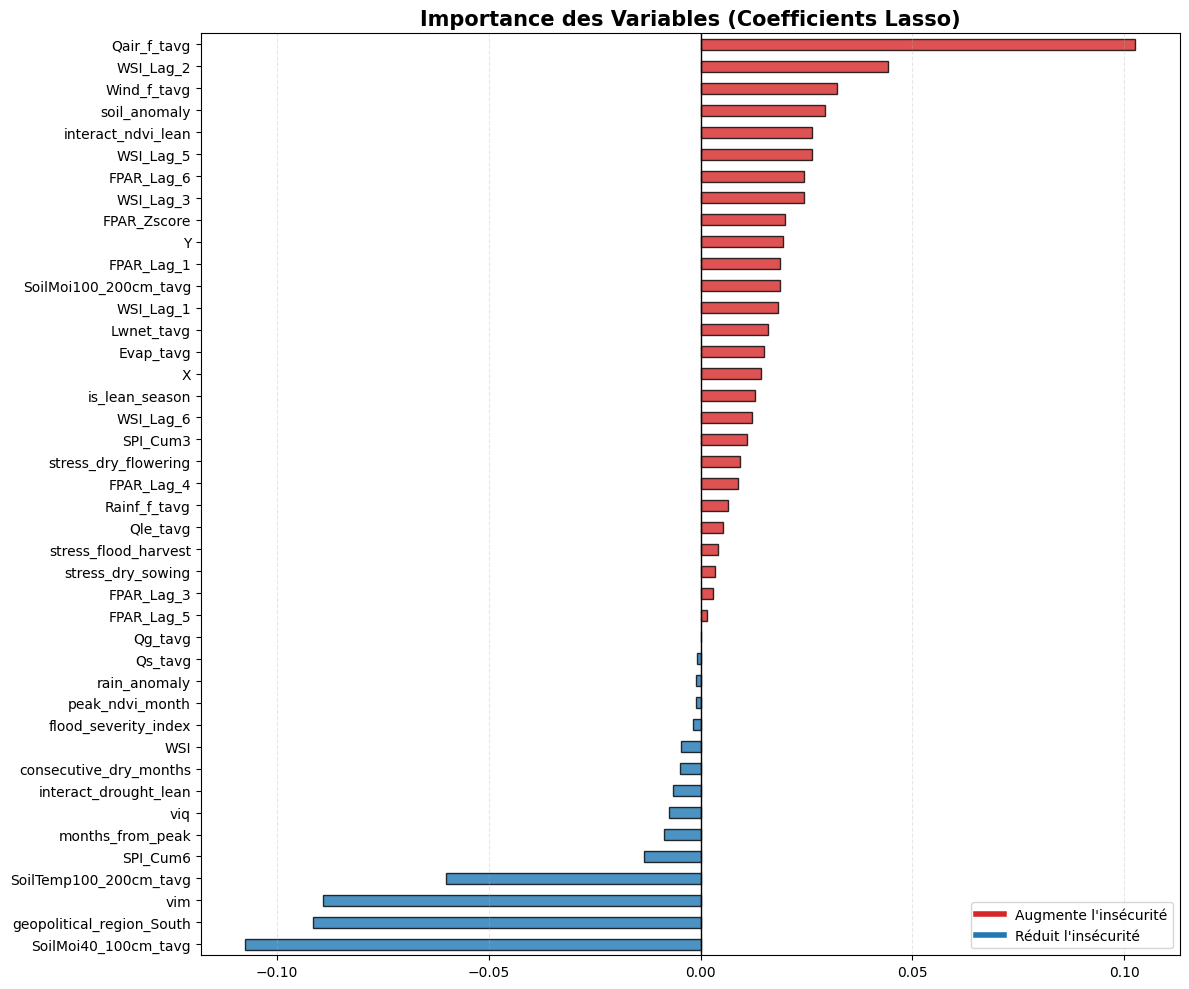

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Extraction et tri
lasso_coefs = pd.Series(lasso.coef_, index=X_final.columns)
selected_features = lasso_coefs[lasso_coefs != 0].sort_values(ascending=True)

# 2. Graphique
plt.figure(figsize=(12, 10))
colors = ['#d62728' if x > 0 else '#1f77b4' for x in selected_features]

selected_features.plot(kind='barh', color=colors, edgecolor='black', alpha=0.8)

# 3. Cosmétique
plt.title("Importance des Variables (Coefficients Lasso)", fontsize=15, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Correction de la légende (Line2D a besoin de listes vides pour x et y)
legend_elements = [
    Line2D([], [], color='#d62728', lw=4, label="Augmente l'insécurité"),
    Line2D([], [], color='#1f77b4', lw=4, label="Réduit l'insécurité")
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [50]:
# 1. Extraction des coefficients non nuls
lasso_coefs = pd.Series(lasso.coef_, index=X_final.columns)
selected_features_series = lasso_coefs[lasso_coefs != 0].abs().sort_values(ascending=False)

# 2. Création de la liste textuelle
selected_list = selected_features_series.index.tolist()

print("=== LISTE DES VARIABLES CONSERVÉES PAR LE LASSO ===")
for i, var in enumerate(selected_list, 1):
    coef_val = lasso_coefs[var]
    print(f"{i}. {var} (Coefficient: {coef_val:.6f})")

# 3. Optionnel : Exporter en format texte pour copier-coller facilement
print("\nFormat pour copier-coller :")
print(selected_list)

=== LISTE DES VARIABLES CONSERVÉES PAR LE LASSO ===
1. SoilMoi40_100cm_tavg (Coefficient: -0.107499)
2. Qair_f_tavg (Coefficient: 0.102695)
3. geopolitical_region_South (Coefficient: -0.091605)
4. vim (Coefficient: -0.089060)
5. SoilTemp100_200cm_tavg (Coefficient: -0.060080)
6. WSI_Lag_2 (Coefficient: 0.044317)
7. Wind_f_tavg (Coefficient: 0.032223)
8. soil_anomaly (Coefficient: 0.029452)
9. interact_ndvi_lean (Coefficient: 0.026318)
10. WSI_Lag_5 (Coefficient: 0.026302)
11. FPAR_Lag_6 (Coefficient: 0.024531)
12. WSI_Lag_3 (Coefficient: 0.024318)
13. FPAR_Zscore (Coefficient: 0.019830)
14. Y (Coefficient: 0.019541)
15. FPAR_Lag_1 (Coefficient: 0.018859)
16. SoilMoi100_200cm_tavg (Coefficient: 0.018648)
17. WSI_Lag_1 (Coefficient: 0.018230)
18. Lwnet_tavg (Coefficient: 0.015971)
19. Evap_tavg (Coefficient: 0.014930)
20. X (Coefficient: 0.014274)
21. SPI_Cum6 (Coefficient: -0.013309)
22. is_lean_season (Coefficient: 0.012749)
23. WSI_Lag_6 (Coefficient: 0.012136)
24. SPI_Cum3 (Coefficie

# ML Testing

 We must achieve a Global MAE strictly below **0.1850** to demonstrate predictive value beyond simple historical seasonality.

In [43]:
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Feature Engineering: Adding temporal/spatial features
df_ml = df.dropna(subset=['inadequate', 'WSI_Lag_3', 'Tair_f_tavg']).copy()
df_ml['month'] = pd.to_datetime(df_ml['time']).dt.month

# 2. Features Selection based on your Phase 3 insights
features = [
    'WSI_Lag_3', 'Tair_f_tavg', 'ndvi_anomaly', 'month',
    'FPAR_Zscore', 'Rainf_f_tavg'
]
# Encode Livelihood Zones
df_ml = pd.get_dummies(df_ml, columns=['dominant_livelihood_zone'], drop_first=True)
X = df_ml.filter(like='dominant_livelihood_zone').join(df_ml[features])
y = df_ml['inadequate']
groups = df_ml['NAME_1'] # For GroupKFold

# 3. Cross-Validation Loop
gkf = GroupKFold(n_splits=5)
scores = []

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    scores.append(mean_absolute_error(y_test, preds))

print(f"Average MAE: {np.mean(scores):.4f}")
print(f"Baseline MAE to beat: 0.1850")

Average MAE: 0.1317
Baseline MAE to beat: 0.1850


In [55]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Redéfinition de la liste des variables sélectionnées par le Lasso
# (On utilise les noms des colonnes PARENTES avant dummification)
selected_lasso = [
    'SoilMoi40_100cm_tavg', 'Qair_f_tavg', 'vim', 'SoilTemp100_200cm_tavg', 
    'WSI_Lag_2', 'Wind_f_tavg', 'soil_anomaly', 'interact_ndvi_lean', 
    'WSI_Lag_5', 'FPAR_Lag_6', 'WSI_Lag_3', 'FPAR_Zscore', 'Y', 
    'FPAR_Lag_1', 'SoilMoi100_200cm_tavg', 'WSI_Lag_1', 'Lwnet_tavg', 
    'Evap_tavg', 'X', 'SPI_Cum6', 'is_lean_season', 'WSI_Lag_6', 
    'SPI_Cum3', 'stress_dry_flowering', 'FPAR_Lag_4', 'months_from_peak', 
    'viq', 'interact_drought_lean', 'Rainf_f_tavg', 'Qle_tavg', 
    'consecutive_dry_months', 'WSI', 'stress_flood_harvest', 
    'stress_dry_sowing', 'FPAR_Lag_3', 'flood_severity_index', 
    'FPAR_Lag_5', 'peak_ndvi_month', 'rain_anomaly', 'Qs_tavg', 'Qg_tavg'
]

# 2. Préparation et Tri Chronologique
# On s'assure que le temps est au bon format et on trie df_final
df_final['time'] = pd.to_datetime(df_final['time'])
df_final = df_final.sort_values('time')

# 3. Création des variables explicatives (X) et de la cible (y)
# On ajoute 'geopolitical_region' qui sera transformée en dummies
X = pd.get_dummies(df_final[selected_lasso + ['geopolitical_region']], drop_first=True)
y = df_final['inadequate']

# Alignement pour supprimer les lignes avec des NaNs
data_ready = pd.concat([X, y], axis=1).dropna()
X_final = data_ready.drop(columns=['inadequate'])
y_final = data_ready['inadequate']

# 4. Validation Croisée Chronologique (TimeSeriesSplit)
tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []
r2_scores = []

print(f"Lancement du Random Forest sur {X_final.shape} variables...")

for train_idx, test_idx in tscv.split(X_final):
    # Split respectant la flèche du temps
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]
    
    # Configuration du modèle (Hyperparamètres robustes pour éviter l'overfitting)
    rf = RandomForestRegressor(
        n_estimators=300, 
        max_depth=10, 
        min_samples_leaf=5, 
        random_state=42, 
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    
    mae_scores.append(mean_absolute_error(y_test, preds))
    r2_scores.append(r2_score(y_test, preds))

# 5. Affichage des résultats finaux
print("\n" + "="*30)
print("RÉSULTATS FINAUX (CV CHRONOLOGIQUE)")
print("="*30)
print(f"MAE Moyen : {np.mean(mae_scores):.4f}")
print(f"R² Moyen  : {np.mean(r2_scores):.3f}")
print(f"Baseline à battre : 0.1850")
print(f"Gain vs Baseline  : {((0.1850 - np.mean(mae_scores))/0.1850)*100:.1f}%")

Lancement du Random Forest sur (737, 42) variables...

RÉSULTATS FINAUX (CV CHRONOLOGIQUE)
MAE Moyen : 0.1439
R² Moyen  : -0.149
Baseline à battre : 0.1850
Gain vs Baseline  : 22.2%


C:\Users\valen\AppData\Local\Temp\ipykernel_11960\4077536711.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


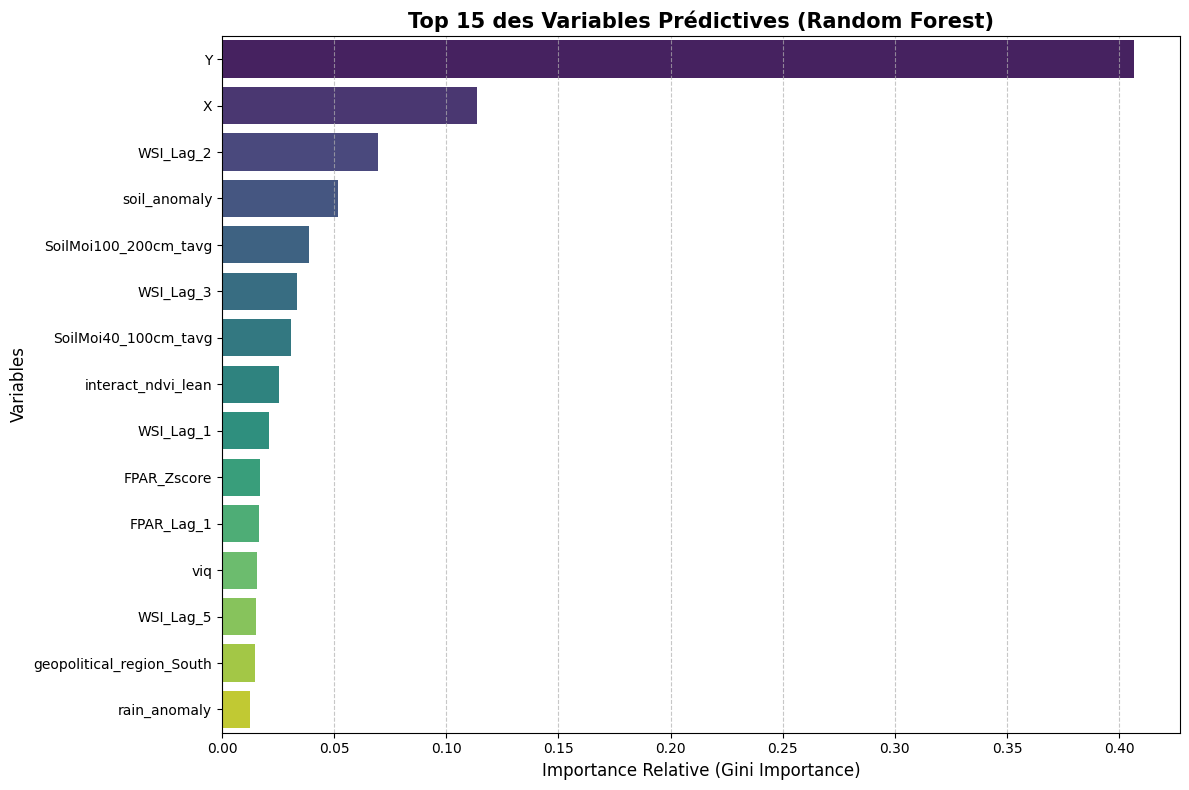

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraction des importances (issues du dernier modèle entraîné dans la boucle)
importances = rf.feature_importances_
feature_names = X_final.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. Tri par importance décroissante
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 3. Visualisation
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title("Top 15 des Variables Prédictives (Random Forest)", fontsize=15, fontweight='bold')
plt.xlabel("Importance Relative (Gini Importance)", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()